#I want find all the Barcelona's games, no matter it was La Liga or European Champion.

In [1]:
import pandas as pd
from pathlib import Path
import json

c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
Target_team = "Barcelona"
Target_season = "2015/2016"
barcelona_event_paths = []

In [3]:
DATA_DIR = Path("D:/UIUC/Projects/World Cup 2026/archive/data")
matches_dir = DATA_DIR / "matches"
events_dir = DATA_DIR / "events"

In [4]:
#interate through all matches file, using rglob to search through global files(includes the lower level folders)
for match_file in matches_dir.rglob("*.json"):
    with open(match_file, "r", encoding="utf-8") as f:
        matches = json.load(f)

        for match in matches:
            home_team = match["home_team"]["home_team_name"]
            away_team = match["away_team"]["away_team_name"]
            # Check if the target team is either the home or away team
            season_name = match.get("season",{}).get("season_name")
            if Target_team in (home_team, away_team) and season_name == Target_season:
                match_id = match["match_id"]
                event_path = events_dir / f"{match_id}.json"
                if event_path.exists():#verify that the event.json exists on disk
                    barcelona_event_paths.append(str(event_path))


print(f"Found {len(barcelona_event_paths)}  Barcelona event files:")
for path in barcelona_event_paths[:5]:  # Print first 5 paths
    print(path)


Found 38  Barcelona event files:
D:\UIUC\Projects\World Cup 2026\archive\data\events\3825660.json
D:\UIUC\Projects\World Cup 2026\archive\data\events\3825637.json
D:\UIUC\Projects\World Cup 2026\archive\data\events\3825645.json
D:\UIUC\Projects\World Cup 2026\archive\data\events\3825627.json
D:\UIUC\Projects\World Cup 2026\archive\data\events\3825617.json


In [ ]:
import numpy as np
df_event = pd.read_json(barcelona_event_paths[0])#the first line indicate 3825660
df_event.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,foul_committed,shot,goalkeeper,out,miscontrol,ball_recovery,block,bad_behaviour,injury_stoppage,substitution
0,bfff84ec-168e-4fe6-a8d4-dc1b66fb5b73,1,1,2026-07-27 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,44be95b2-6799-4864-a60b-8886397359fd,2,1,2026-07-27 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8eb070a8-182c-4312-a8e5-6736587d0f25,3,1,2026-07-27 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05bfc29c-96d0-4df5-9dd4-bb5f8a9fdbb5,4,1,2026-07-27 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79df2e38-1116-4691-a05e-9eed66ae8166,5,1,2026-07-27 00:00:00.495,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 217, 'name': 'Barcelona'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The first Chapter would be the description statistics. I would calculate these data of FC Barcelona in a single game and then apply the same method to every its game.

The first index is the possession rate. I used the advanced method which is equal to the time in FCB's possession devided by the total time of the game.

In [7]:
#break down all events related to FCB and its opponent
df_event["team_name"] = df_event["team"].apply(lambda x: x["name"])
#"team" is a dictionary which contains the team_id and team_name 
object_events = df_event[df_event["team_name"] == Target_team].copy()
opp_events = df_event[df_event["team_name"] != Target_team].copy()

In [8]:
total_possession_time = df_event["possession"].max()
barca_possession_time = object_events["possession"].nunique()
possession_rate = round(barca_possession_time / total_possession_time * 100, 2) if total_possession_time > 0 else 0
print(f"possession rate : {possession_rate}")
#It seems like we cannot use these data to calculate the possession rate. Even it was Barcelona in 09 season. 
# It cannot have a rate highter than 80%.


possession rate : 92.78


# FCB's attack data: 
 -- shots, shots on target, goals and corners

In [9]:
all_shots = object_events[object_events["type"].apply(lambda x: x["name"]) == "Shot"]
total_shot = len(all_shots)
shot_on_target = len(all_shots[all_shots["shot"].apply(lambda x: x["outcome"]["name"]).isin(["Goal","Saved","Saved To Post"])])
goals = len(all_shots[all_shots["shot"].apply(lambda x: x["outcome"]["name"]) == "Goal"])
print(f"Total shots: {total_shot}\n"
      f"Total shots on Target: {shot_on_target}\n"
      f"Goals: {goals}",
)


Total shots: 20
Total shots on Target: 9
Goals: 3


In [10]:
from mplsoccer import VerticalPitch, Pitch
import matplotlib.pyplot as plt
non_goal_shots = all_shots[all_shots["shot"].str["outcome"]!= "Goal"]
df = df_event.copy()
df["x"] = df["location"].str[0]
df["y"] = df["location"].str[1]
#shots inside the box
all_shots = df[df["type"].str["name"] == "Shot"].copy()
all_shots["in_box"] = all_shots["x"] > 102
in_box_shot = all_shots["in_box"].sum()
out_box_shot = (~all_shots["in_box"]).sum()

In [11]:
# 左/中/右路射门
def zone(y):
    if y < 26.67:
        return "Right"
    elif y > 53.33:
        return "Left"
    else:
        return "Center"
all_shots["zone"] = all_shots["y"].apply(zone)
zone_count = all_shots["zone"].value_counts()

# 打印统计结果
print(f"禁区内射门：{in_box_shot} | 禁区外远射：{out_box_shot}")
print("左右中路射门分布：\n", zone_count)

禁区内射门：19 | 禁区外远射：6
左右中路射门分布：
 zone
Center    22
Right      2
Left       1
Name: count, dtype: int64


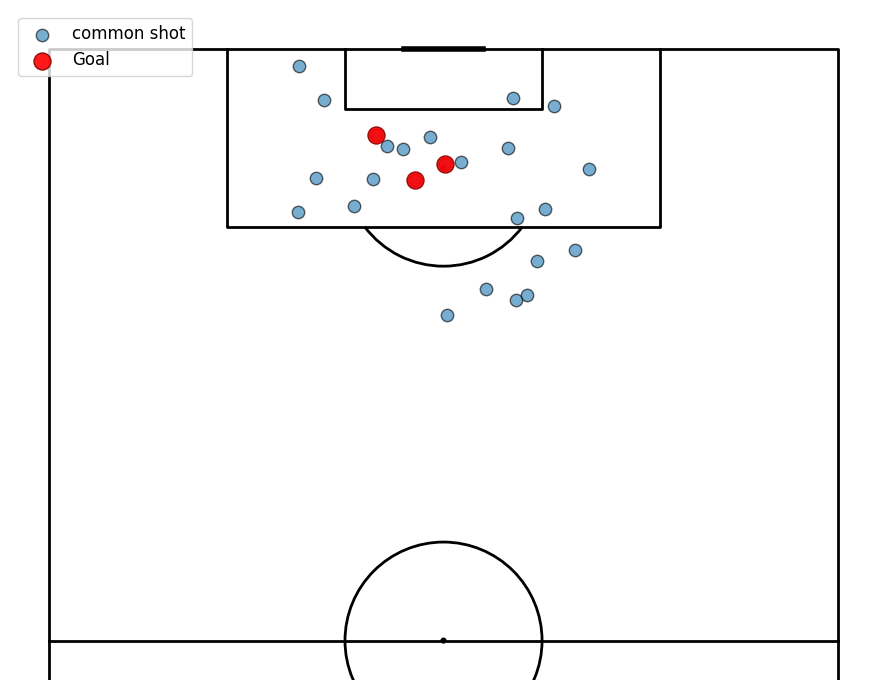

In [12]:
pitch = VerticalPitch(
    pitch_type= "statsbomb",
    half= True,
    line_color= "black",
    pitch_color="white"
)
fig, ax= pitch.draw(figsize=(10,7))
#non-gaol shots
non_goal_shots = all_shots[all_shots["shot"].str["outcome"]!= "Goal"]
goal_shots = all_shots[all_shots["shot"].str["outcome"].str["name"]=="Goal"]
pitch.scatter(
    x =non_goal_shots["x"],
    y =non_goal_shots["y"],
    s= 80,
    alpha = 0.6,
    edgecolor = "black",
    ax= ax,
    label = "common shot"
)
pitch.scatter(
    x=goal_shots["x"],
    y=goal_shots["y"],
    c="red",
    s= 150,
    alpha = 0.9,
    edgecolor = "darkred",
    marker="o",
    ax= ax,
    label = "Goal"
)
ax.legend(loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

# Pass
- Set pieces: corners, free kicks and penalty

In [33]:
passes = object_events[object_events["type"].apply(lambda x: x["name"]) =="Pass"].copy()
total_pass = len(passes)
set_pieces_pass = passes[passes["type"].isin(["Corner","Free Kick","Penalty"])]
total_set_piece = len(set_pieces_pass)
#subdevided data for corners, free kicks and penalties
fk_count = len(set_pieces_pass[set_pieces_pass["type"] == "Free Kick"])
corner_count = len(set_pieces_pass[set_pieces_pass["type"] == "Corner"])
pl_count = len(set_pieces_pass[set_pieces_pass["type"] == "Penalty"])
passes["start_x"]= passes["location"].str[0]
passes["start_y"]= passes["location"].str[1]
#pass end location
passes["end_x"]= passes["pass"].str["end_location"].str[0]
passes["end_y"]= passes["pass"].str["end_location"].str[1]

passes["player_name"] = passes["player"].str["name"]
passes["team_name"] = passes["team"].str["name"]
# 按球员分组，统计传球数量
player_pass_count = passes.groupby(["team_name", "player_name"]).size().reset_index()
# 给计数列改名
player_pass_count.rename(columns={0: "总传球数"}, inplace=True)
# ascending=False 降序，传球多的排在最上面
player_pass_sorted = player_pass_count.sort_values(by="总传球数", ascending=False)

# 重置行索引，方便查看
player_pass_sorted = player_pass_sorted.reset_index(drop=True)

# 打印完整排名表
print("本场球员传球排名（从多到少）：")
print(player_pass_sorted)

本场球员传球排名（从多到少）：
    team_name                    player_name  总传球数
0   Barcelona       Sergio Busquets i Burgos    94
1   Barcelona               Jordi Alba Ramos    93
2   Barcelona          Daniel Alves da Silva    83
3   Barcelona  Neymar da Silva Santos Junior    72
4   Barcelona           Andrés Iniesta Luján    71
5   Barcelona         Sergi Roberto Carnicer    65
6   Barcelona                 Jérémy Mathieu    60
7   Barcelona          Gerard Piqué Bernabéu    58
8   Barcelona       Munir El Haddadi Mohamed    31
9   Barcelona       Luis Alberto Suárez Díaz    26
10  Barcelona     Claudio Andrés Bravo Muñoz    23
11  Barcelona            Marc Bartra Aregall     8
12  Barcelona        Sandro Ramírez Castillo     3


In [34]:

def get_player_data(df, keyword):
    filter_df = df[df["player_name"].str.contains(keyword, case=False, na=False)]
    if len(filter_df)== 0:
        return None
    unique_names = filter_df["player_name"].unique()
    return filter_df

target_player="Busquets"
player_passes = get_player_data(passes, target_player)

Busquets 本场总传球次数：94


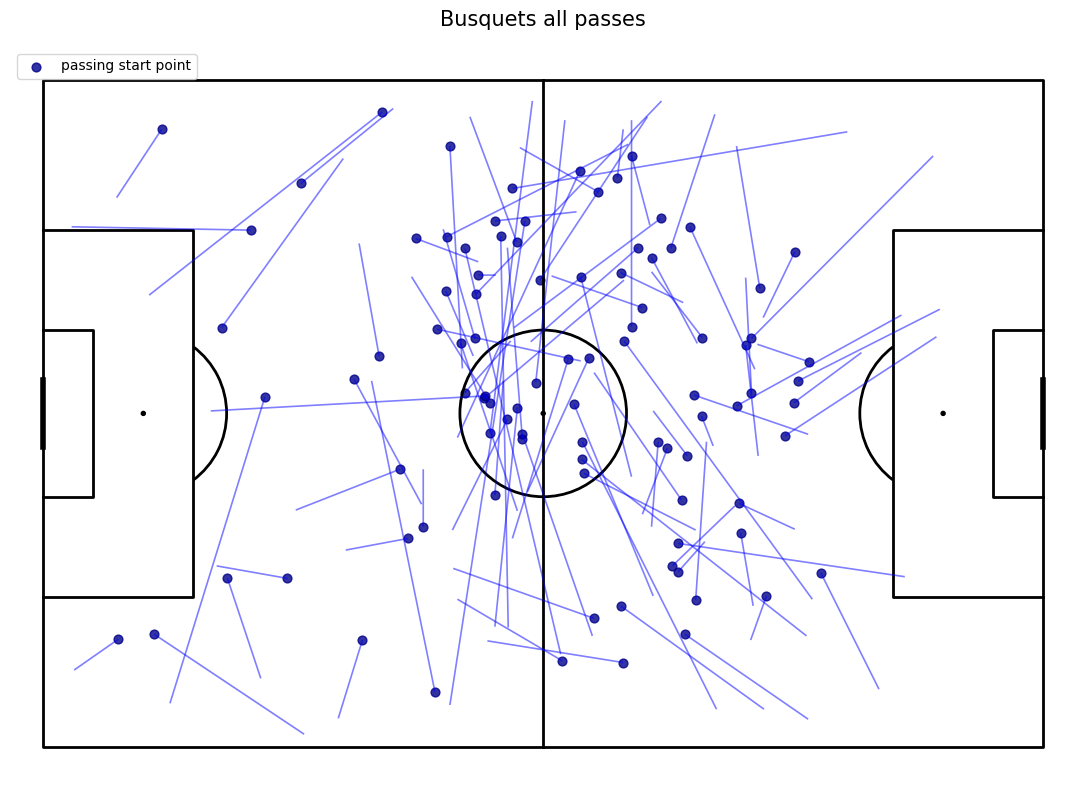

In [35]:

# Judge if the pass data is Na or not
if len(player_passes) == 0:
    print(f"{target_player} 本场无传球数据")
else:
    print(f"{target_player} 本场总传球次数：{len(player_passes)}")
# 创建标准横向球场（StatsBomb坐标系）
pitch = Pitch(
    pitch_type="statsbomb",
    line_color="black",
    pitch_color="white",
    line_zorder=2
)
fig, ax = pitch.draw(figsize=(12, 8))

# 1. 绘制所有传球线段（浅蓝色半透明线路）
pitch.lines(
    xstart=player_passes["start_x"],
    ystart=player_passes["start_y"],
    xend=player_passes["end_x"],
    yend=player_passes["end_y"],
    color="blue",
    lw=1.2,    # 线条粗细
    alpha=0.5, # 透明度，传球密集不会完全遮挡
    ax=ax
)

# 2. 散点标记每一次传球的起点（深蓝色圆点）
pitch.scatter(
    x=player_passes["start_x"],
    y=player_passes["start_y"],
    c="darkblue",
    s=40,
    alpha=0.8,
    ax=ax,
    label="passing start point"
)

# 图表美化
ax.set_title(f"{target_player} all passes", fontsize=15, pad=15)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# plt.savefig(f"{target_player}_pass_map.png", dpi=300, bbox_inches="tight")


本场巴萨有传球的球员共 13 人
球员名单： ['Neymar da Silva Santos Junior' 'Luis Alberto Suárez Díaz'
 'Sergio Busquets i Burgos' 'Andrés Iniesta Luján' 'Jérémy Mathieu'
 'Gerard Piqué Bernabéu' 'Jordi Alba Ramos' 'Daniel Alves da Silva'
 'Sergi Roberto Carnicer' 'Munir El Haddadi Mohamed'
 'Claudio Andrés Bravo Muñoz' 'Marc Bartra Aregall'
 'Sandro Ramírez Castillo']


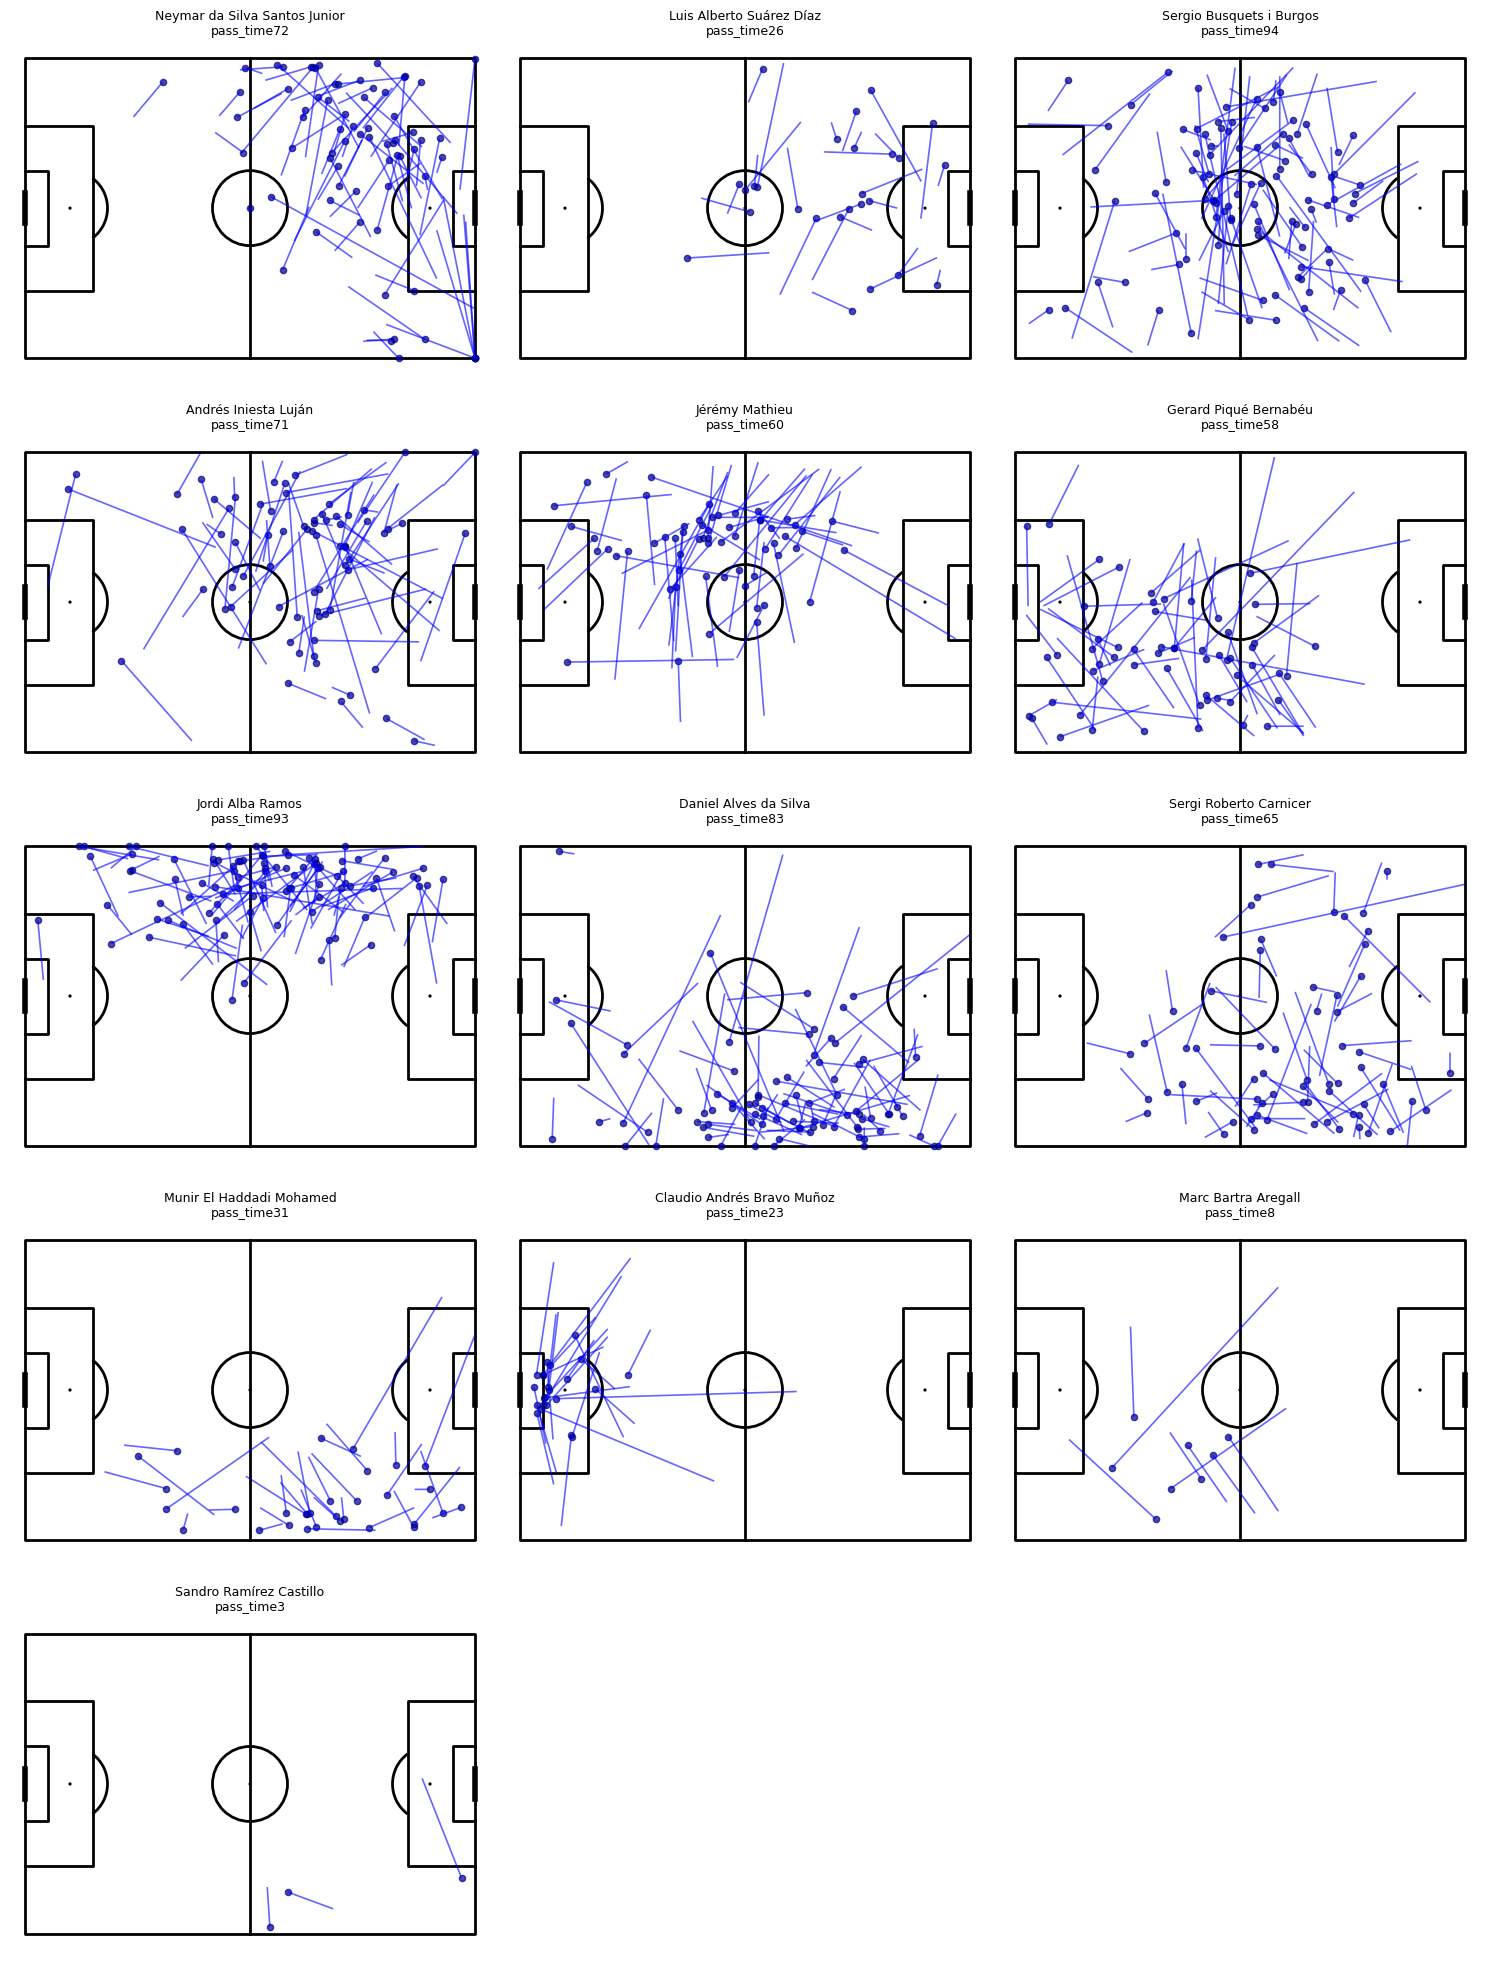

In [41]:

barca_player_names = passes["player_name"].unique()
print(f"本场巴萨有传球的球员共 {len(barca_player_names)} 人")
print("球员名单：", barca_player_names)

import math

player_count = len(barca_player_names)
cols = 3
rows = math.ceil(player_count / cols)

# 创建总画布
fig, ax_list = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
ax_list = ax_list.flatten()

# 循环绘制每个球员子图
for idx, player_name in enumerate(barca_player_names):
    ax = ax_list[idx]
    player_df = passes[passes["player_name"] == player_name].copy()
    valid_lines = player_df.dropna(subset=["start_x", "start_y", "end_x", "end_y"])

    pitch = Pitch(pitch_type="statsbomb", line_color="black", pitch_color="white")
    pitch.draw(ax=ax)

    # 绘制传球线
    if len(valid_lines) > 0:
        pitch.lines(valid_lines["start_x"], valid_lines["start_y"],
                     valid_lines["end_x"], valid_lines["end_y"],
                     color="blue", lw=1.2, alpha=0.6, ax=ax)
    # 绘制起点散点
    pitch.scatter(player_df["start_x"], player_df["start_y"], c="darkblue", s=20, alpha=0.7, ax=ax)
    ax.set_title(f"{player_name}\npass_time{len(player_df)}", fontsize=9)

# 隐藏多余空白子图
for idx in range(player_count, len(ax_list)):
    ax_list[idx].axis("off")

plt.tight_layout()
plt.show()

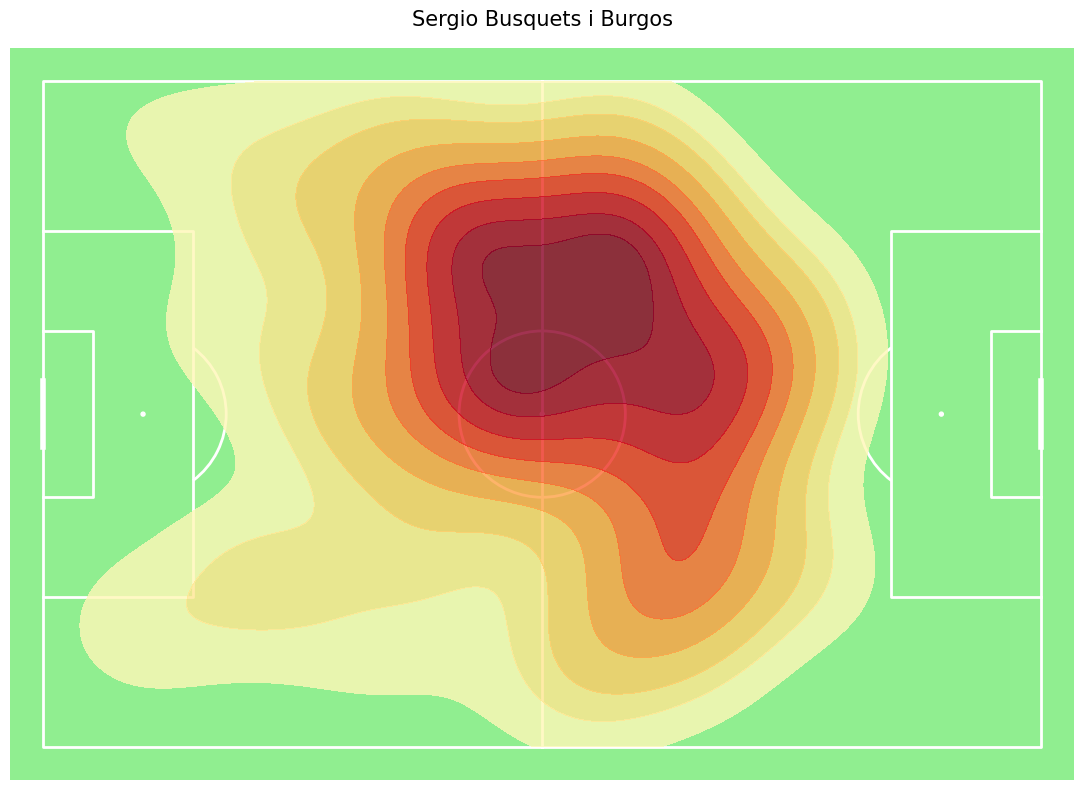

In [57]:
def draw_player_all_action_heatmap(full_event_df, player_keyword):
    # 筛选该球员全部事件
    full_event_df["player_name"] = full_event_df["player"].str["name"]
    player_all_actions = full_event_df[full_event_df["player_name"].str.contains(player_keyword, case=False,na=False)].copy()
    
    # 提取所有动作坐标location
    player_all_actions["act_x"] = player_all_actions["location"].str[0]
    player_all_actions["act_y"] = player_all_actions["location"].str[1]
    valid_data = player_all_actions.dropna(subset=["act_x", "act_y"])
    if len(valid_data) == 0:
        print(f"{player_all_actions['player_name'].iloc[0]} 无有效场上坐标数据")
        return

    
    x = valid_data["act_x"]
    y = valid_data["act_y"]

    pitch = Pitch(pitch_type="statsbomb", line_color="white", pitch_color="lightgreen")
    fig, ax = pitch.draw(figsize=(12,8))
    pitch.kdeplot(x=x, y=y, ax=ax, cmap="YlOrRd", fill=True,shade_lowest=False, alpha=0.8)
    ax.set_title(f"{player_all_actions['player_name'].iloc[0]}", fontsize=15,pad= 16)
    plt.show()

draw_player_all_action_heatmap(object_events, "Busquets")

TypeError: BasePitchSoccer.__init__() got an unexpected keyword argument 'orientation'

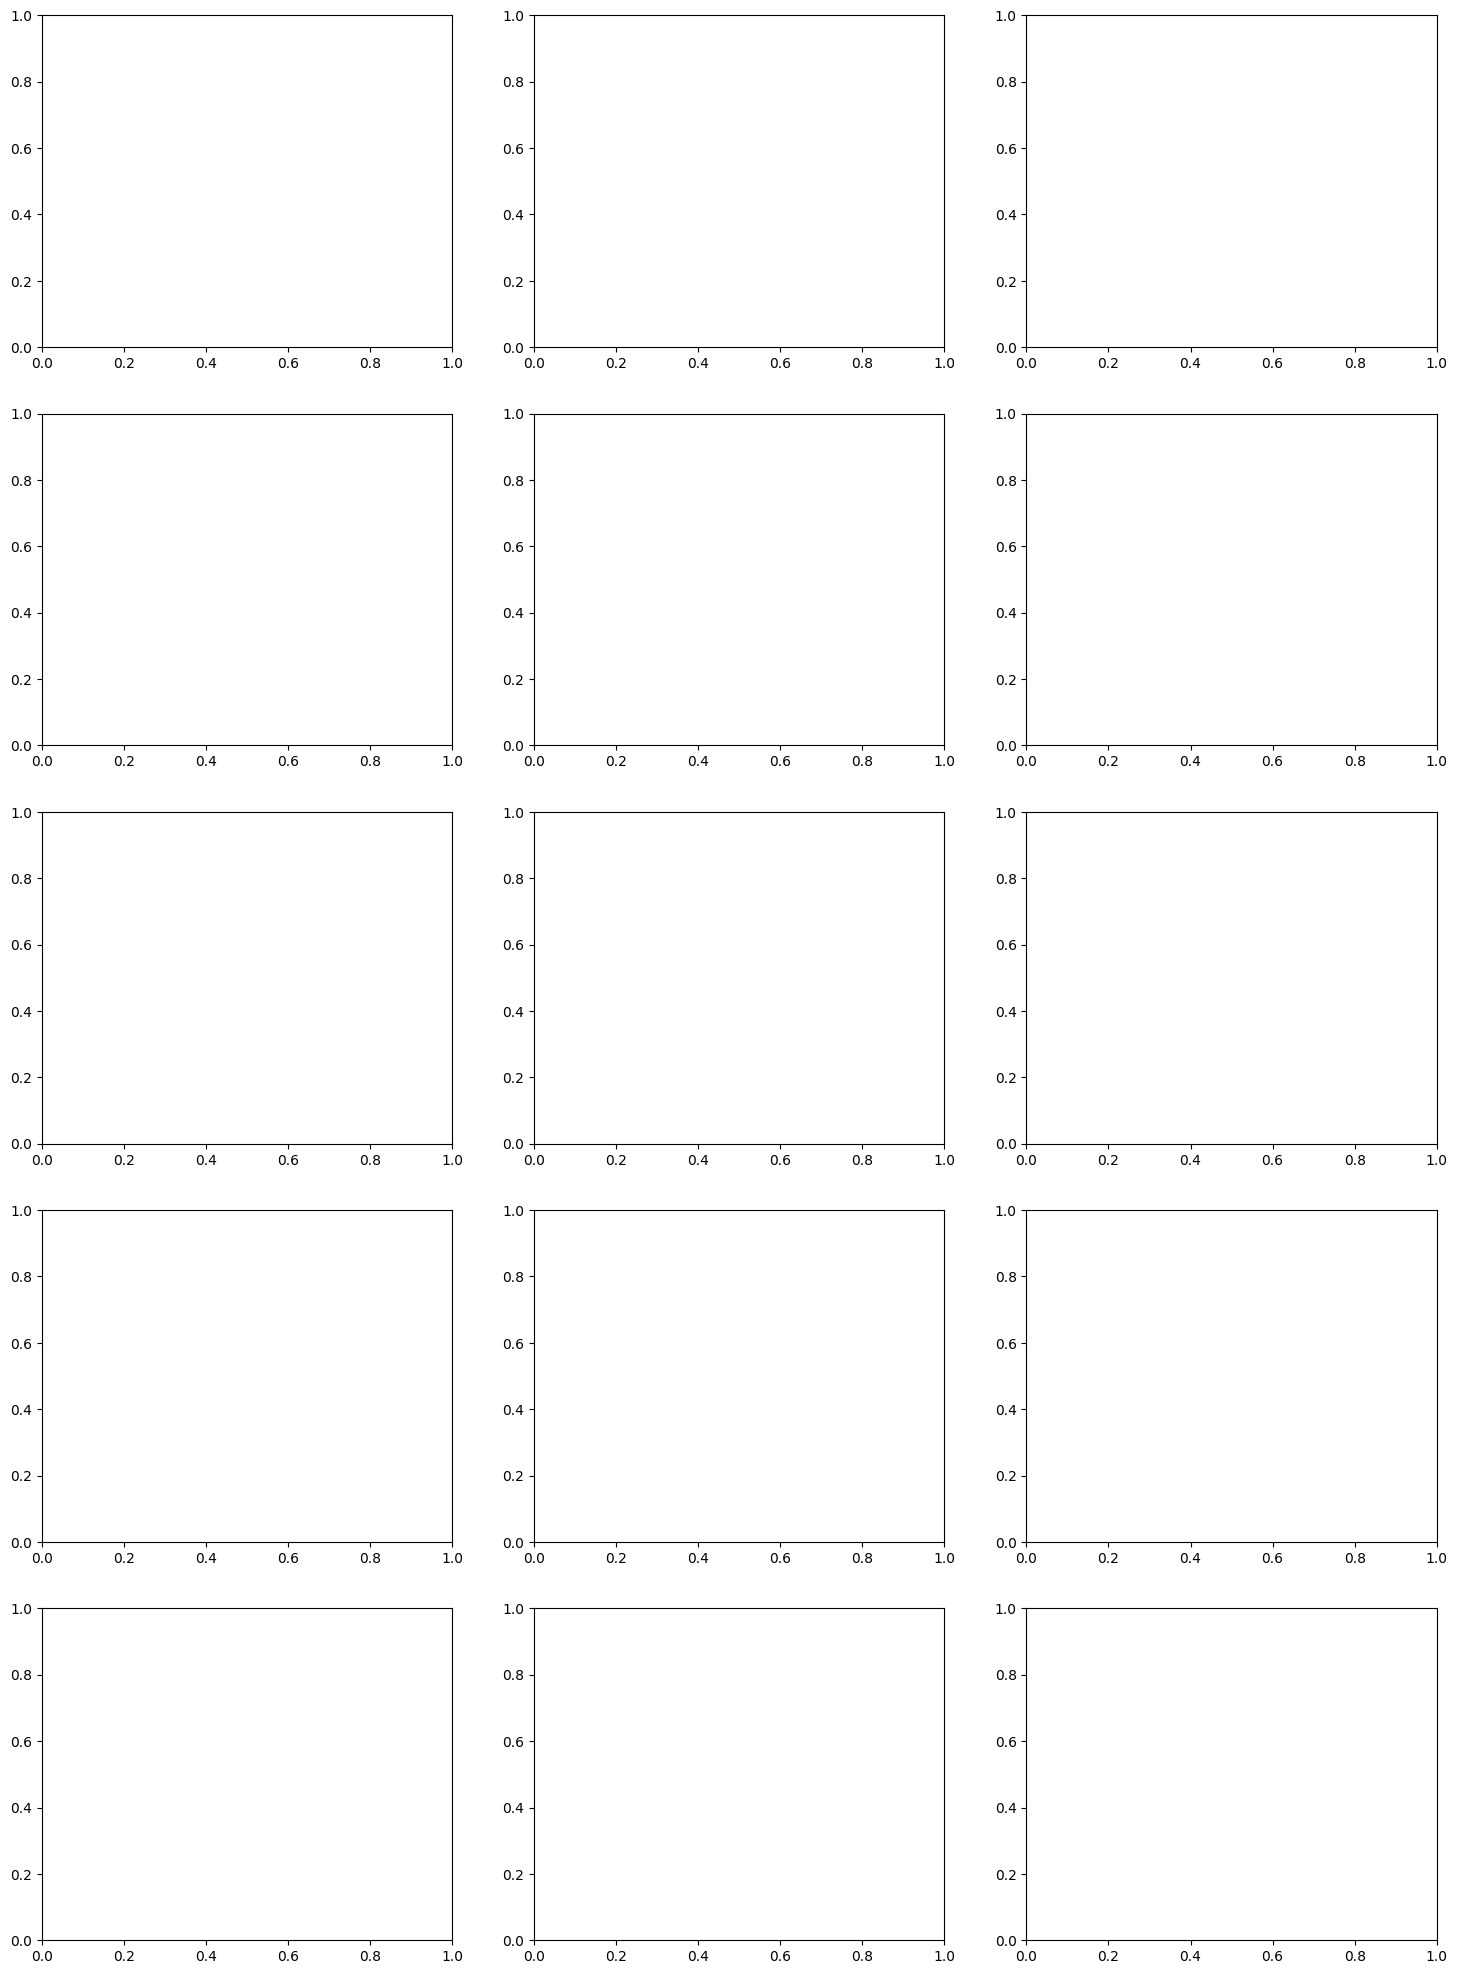

In [58]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import math

def draw_all_barca_heatmap_one_canvas(full_event_df):
    # 1. 预处理：筛选巴萨全队所有事件
    full_event_df["player_name"] = full_event_df["player"].str["name"]
    full_event_df["team_name"] = full_event_df["team"].str["name"]
    barca_all_events = full_event_df[full_event_df["team_name"] == "Barcelona"].copy()

    # 获取所有有场上动作的巴萨球员全名（去重）
    barca_player_names = barca_all_events["player_name"].unique()
    total_player = len(barca_player_names)
    

    # 2. 自动计算子图行列布局（3列排版，自适应行数）
    cols = 3
    rows = math.ceil(total_player / cols)
    # 创建超大总画布，适配多张子图
    fig, ax_list = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    ax_list = ax_list.flatten()  # 把二维子图数组转为一维，方便循环索引

    # 3. 循环遍历每一名巴萨球员，逐个绘制子热力图
    for idx, player_name in enumerate(barca_player_names):
        current_ax = ax_list[idx]
        # 筛选当前球员全部场上事件
        player_actions = barca_all_events[barca_all_events["player_name"] == player_name].copy()
        # 拆分坐标并清洗空值
        player_actions["act_x"] = player_actions["location"].str[0]
        player_actions["act_y"] = player_actions["location"].str[1]
        valid_data = player_actions.dropna(subset=["act_x", "act_y"])

        # 创建球场模板（和示例图配色、底色统一）
        pitch = Pitch(
            pitch_type="statsbomb",
            line_color="white",
            pitch_color="green",
            orientation="horizontal"
        )
        pitch.draw(ax=current_ax)

        # 有有效点位才绘制热力，无数据则空白球场
        if len(valid_data) > 0:
            pitch.kdeplot(
                x=valid_data["act_x"],
                y=valid_data["act_y"],
                ax=current_ax,
                cmap="YlOrRd",
                shade=True,
                shade_lowest=False,
                alpha=0.85
            )
        # 子图标题：球员姓名+总场上动作数量
        current_ax.set_title(f"{player_name}\n{len(valid_data)}", fontsize=9)

    # 4. 隐藏多余空白子图（球员数量不足填满网格时）
    for empty_idx in range(total_player, len(ax_list)):
        ax_list[empty_idx].axis("off")

    # 整体画布优化，避免文字、子图重叠
    plt.tight_layout()
    # 可选：保存高清大图到本地
    # plt.savefig("Barcelona_All_Player_Heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

# 调用执行，传入完整原始事件表 object_events
draw_all_barca_heatmap_one_canvas(object_events)